# Unfolding: old vs new GENIE systematics

Same Gen1 measurement / response / model as `unfolding.ipynb`, but the input
covariance uses **old** vs **new** GENIE `xsec` fractional covariances.

* **Non-GENIE** categories fixed from unfolding-era
  `systematics-final/CategorySummary/category_syst_summary.npz`
* **Old GENIE** = that summary’s `genie_xsec` (unfolding-era)
* **New GENIE** = sum of Aug24 `sel_mup` mode disks + latest Ar23p
  (`syst_genie_inspect.mode_totals_ar23p_standalone`)

Each figure is **1×2**: left = Old, right = New (extracted cross section).


In [1]:
%load_ext autoreload
%autoreload 2


In [2]:
from __future__ import annotations

import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pickle

REPO = Path("/exp/sbnd/app/users/munjung/xsec/freeze/cafpyana")
sys.path.insert(0, str(REPO))

from analysis_village.numucc_1p0pi.dataset_locations import PLOTS_BASE
from analysis_village.numucc_1p0pi.final_selected_evt_vars import CORE_SELECTED_EVT_VARIABLE_CONFIGS
from analysis_village.numucc_1p0pi.syst_genie_inspect import (
    load_cov_mat_dict,
    mode_totals_ar23p_standalone,
    sum_cov_fracs,
)
from analysis_village.numucc_1p0pi.utils import cov_from_fraccov, get_response_matrix
from analysis_village.numucc_1p0pi.variable_configs import VariableConfig
from analysis_village.unfolding.wienersvd import WienerSVD

DATA_RESULTS = Path("/exp/sbnd/data/users/munjung/xsec/RESULTS/DATA_RESULTS")
GEN1_CACHE_PATH = DATA_RESULTS / "Gen1_unfold_cache_efielddet_noneutron.pkl"
CATEGORY_SUMMARY_NPZ = Path(
    "/exp/sbnd/data/users/munjung/plots/numucc1p0pi"
    "/systematics-final/CategorySummary/category_syst_summary.npz"
)
SYST_BASE = Path("/exp/sbnd/data/users/munjung/xsec/numucc_1p0pi")

_AR23P_NEW = next(
    (
        p
        for p in (
            SYST_BASE / "syst_disk_sel_mup_20260912_Ar23p/GENIE/cov_mat_dict.pkl",
            SYST_BASE / "syst_disk_sel_mup_Aug24_Ar23p/GENIE/cov_mat_dict.pkl",
        )
        if p.is_file()
    ),
    SYST_BASE / "syst_disk_sel_mup_20260912_Ar23p/GENIE/cov_mat_dict.pkl",
)
GROUP_SOURCES_NEW = {
    "CCQE": SYST_BASE / "syst_disk_sel_mup_Aug24_CCQE/GENIE/cov_mat_dict.pkl",
    "MEC": SYST_BASE / "syst_disk_sel_mup_Aug24_MEC/GENIE/cov_mat_dict.pkl",
    "RES": SYST_BASE / "syst_disk_sel_mup_Aug24_RES/GENIE/cov_mat_dict.pkl",
    "nonRES": SYST_BASE / "syst_disk_sel_mup_Aug24_nonRES/GENIE/cov_mat_dict.pkl",
    "DIS": SYST_BASE / "syst_disk_sel_mup_Aug24_DIS/GENIE/cov_mat_dict.pkl",
    "Other": SYST_BASE / "syst_disk_sel_mup_Aug24_Other/GENIE/cov_mat_dict.pkl",
    "Ar23p": _AR23P_NEW,
}

OUT_DIR = Path(PLOTS_BASE) / "unfolding_genie_comparison"
OUT_DIR.mkdir(parents=True, exist_ok=True)

C_TYPE = 2
NORM_TYPE = 0.0
SAVE_FIGS = True
FIG_DPI = 140
PLOT_VARS = [
    "integrated",
    "tki-del_Tp",
    "tki-del_alpha",
    "tki-del_phi",
    "muon-p",
    "proton-p",
]

vc_by = {vc.var_save_name: vc for vc in CORE_SELECTED_EVT_VARIABLE_CONFIGS}
vc_by["integrated"] = VariableConfig.all_events()

print("Gen1 cache :", GEN1_CACHE_PATH, "exists=", GEN1_CACHE_PATH.is_file())
print("Category   :", CATEGORY_SUMMARY_NPZ, "exists=", CATEGORY_SUMMARY_NPZ.is_file())
print("OUT_DIR    :", OUT_DIR)
for m, p in GROUP_SOURCES_NEW.items():
    print(f"  new {m:7s} exists={p.is_file()}  {p}")


Gen1 cache : /exp/sbnd/data/users/munjung/xsec/RESULTS/DATA_RESULTS/Gen1_unfold_cache_efielddet_noneutron.pkl exists= True
Category   : /exp/sbnd/data/users/munjung/plots/numucc1p0pi/systematics-final/CategorySummary/category_syst_summary.npz exists= True
OUT_DIR    : /exp/sbnd/data/users/munjung/plots/numucc1p0pi/unfolding_genie_comparison
  new CCQE    exists=True  /exp/sbnd/data/users/munjung/xsec/numucc_1p0pi/syst_disk_sel_mup_Aug24_CCQE/GENIE/cov_mat_dict.pkl
  new MEC     exists=True  /exp/sbnd/data/users/munjung/xsec/numucc_1p0pi/syst_disk_sel_mup_Aug24_MEC/GENIE/cov_mat_dict.pkl
  new RES     exists=True  /exp/sbnd/data/users/munjung/xsec/numucc_1p0pi/syst_disk_sel_mup_Aug24_RES/GENIE/cov_mat_dict.pkl
  new nonRES  exists=True  /exp/sbnd/data/users/munjung/xsec/numucc_1p0pi/syst_disk_sel_mup_Aug24_nonRES/GENIE/cov_mat_dict.pkl
  new DIS     exists=True  /exp/sbnd/data/users/munjung/xsec/numucc_1p0pi/syst_disk_sel_mup_Aug24_DIS/GENIE/cov_mat_dict.pkl
  new Other   exists=True  /

In [3]:
with open(GEN1_CACHE_PATH, "rb") as f:
    gen1_cache = pickle.load(f)

category_summary = np.load(CATEGORY_SUMMARY_NPZ, allow_pickle=True)

groups_new = {}
for mode, path in GROUP_SOURCES_NEW.items():
    if not Path(path).is_file():
        print("WARNING: missing", mode, path)
        continue
    groups_new[mode] = load_cov_mat_dict(path)
    print("loaded new", mode)


def xsec_unit_from_entry(entry) -> float:
    model = np.asarray(entry["model"], dtype=float)
    nevts_allmc = np.asarray(entry["ret_signal_hists"]["nevts_allmc"], dtype=float)
    return float(np.mean(model / nevts_allmc))


def build_response(sig, bins):
    bins = np.asarray(bins, dtype=float)
    if len(bins) == 2:
        reco_vs_true = np.array([[float(np.sum(sig["nevts_sel_truth"]))]], dtype=float)
    else:
        reco_vs_true, _, _ = np.histogram2d(
            np.asarray(sig["var_sel_truth"], dtype=float),
            np.asarray(sig["var_sel_reco"], dtype=float),
            weights=np.asarray(sig["wgt_sel_truth"], dtype=float),
            bins=bins,
        )
    nevts_allmc = np.asarray(sig["nevts_allmc"], dtype=float)
    nevts_sel_truth = np.asarray(sig["nevts_sel_truth"], dtype=float)
    eff = nevts_sel_truth / nevts_allmc
    return get_response_matrix(reco_vs_true, eff)


def chi2_vs_model(unfold, model, bins):
    bins = np.asarray(bins, dtype=float)
    bw = np.diff(bins) if len(bins) > 2 else np.array([1.0])
    U = np.asarray(unfold["unfold"], dtype=float)
    As = np.asarray(unfold["AddSmear"], dtype=float)
    Uc = np.asarray(unfold["UnfoldCov"], dtype=float)
    cov_pw = Uc * np.outer(1.0 / bw, 1.0 / bw)
    U_pw = U / bw
    M_pw = (As @ np.asarray(model, dtype=float)) / bw
    mask = (U_pw > 0) & (M_pw > 0)
    diff = U_pw[mask] - M_pw[mask]
    chi2 = float(diff @ np.linalg.solve(cov_pw[np.ix_(mask, mask)], diff))
    return chi2, int(np.sum(mask))


def new_genie_cov_frac(slug: str) -> np.ndarray:
    mt = mode_totals_ar23p_standalone(groups_new, slug, "xsec")
    tot = sum_cov_fracs(list(mt.values()))
    if tot is None:
        raise KeyError(f"no new GENIE cov for {slug}")
    return np.asarray(tot, dtype=float)


def total_xsec_frac(slug: str, *, era: str) -> np.ndarray:
    """Unfolding-era non-GENIE + old/new GENIE xsec."""
    cell = category_summary[slug].item()
    total = np.asarray(cell["total_xsec"]["cov_frac"], dtype=float)
    genie_old = np.asarray(cell["categories"]["genie_xsec"]["cov_frac"], dtype=float)
    if era == "old":
        return total
    if era == "new":
        genie_new = new_genie_cov_frac(slug)
        if genie_new.shape != genie_old.shape:
            raise ValueError(
                f"{slug}: new GENIE shape {genie_new.shape} != old {genie_old.shape}"
            )
        return total - genie_old + genie_new
    raise ValueError(era)


XSEC_UNIT = xsec_unit_from_entry(gen1_cache["tki-del_Tp"])
print(f"xsec_unit = {XSEC_UNIT:.6e}")
print("Gen1 vars:", sorted(gen1_cache.keys()))


loaded new CCQE
loaded new MEC
loaded new RES
loaded new nonRES
loaded new DIS
loaded new Other
loaded new Ar23p
xsec_unit = 6.657611e-43
Gen1 vars: ['muon-dir_z', 'muon-p', 'proton-dir_z', 'proton-p', 'tki-del_Tp', 'tki-del_Tp_x', 'tki-del_Tp_y', 'tki-del_alpha', 'tki-del_p', 'tki-del_phi']


## Unfold with Old / New GENIE covariances


In [4]:
def ingredients_for_var(vsn: str):
    """Return bins, response, measured, model, nevts_sel_reco for a CORE var."""
    if vsn == "integrated":
        # Build from tki-del_Tp sums (same selection), matching unfolding.ipynb.
        entry = gen1_cache["tki-del_Tp"]
        sig = entry["ret_signal_hists"]
        vc = vc_by["integrated"]
        bins = np.asarray(vc.bins, dtype=float)

        def _sum(a):
            return np.asarray([float(np.sum(a))], dtype=float)

        nevts_allmc = _sum(sig["nevts_allmc"])
        nevts_sel_reco = _sum(sig["nevts_sel_reco"])
        nevts_sel_truth = _sum(sig["nevts_sel_truth"])
        measured = np.asarray([float(np.sum(entry["measured"]))], dtype=float)
        model = nevts_allmc * XSEC_UNIT
        eff = nevts_sel_truth / nevts_allmc
        reco_vs_true = np.array([[float(nevts_sel_truth[0])]], dtype=float)
        response = get_response_matrix(reco_vs_true, eff)
        return vc, bins, response, measured, model, nevts_sel_reco

    entry = gen1_cache[vsn]
    vc = entry.get("var_config") or vc_by[vsn]
    bins = np.asarray(vc.bins, dtype=float)
    sig = entry["ret_signal_hists"]
    measured = np.asarray(entry["measured"], dtype=float)
    model = np.asarray(entry["model"], dtype=float)
    response = build_response(sig, bins)
    nevts_sel_reco = np.asarray(sig["nevts_sel_reco"], dtype=float)
    return vc, bins, response, measured, model, nevts_sel_reco


def run_unfold(vsn: str, era: str):
    vc, bins, response, measured, model, nevts_sel_reco = ingredients_for_var(vsn)
    frac = total_xsec_frac(vsn, era=era)
    Cov = cov_from_fraccov(frac, nevts_sel_reco) * XSEC_UNIT**2
    unfold = WienerSVD(
        response, model, measured, Cov, C_TYPE, NORM_TYPE, stat_scaling=XSEC_UNIT
    )
    chi2, ndof = chi2_vs_model(unfold, model, bins)
    return {
        "vc": vc,
        "bins": bins,
        "measured": measured,
        "model": model,
        "unfold": unfold,
        "frac_cov": frac,
        "chi2": chi2,
        "ndof": ndof,
    }


available = [v for v in PLOT_VARS if v == "integrated" or v in gen1_cache]
available = [v for v in available if v in category_summary.files]
print("plot vars:", available)

results = {"old": {}, "new": {}}
for era in ("old", "new"):
    print(f"\n=== {era.upper()} ===")
    for vsn in available:
        blob = run_unfold(vsn, era)
        results[era][vsn] = blob
        print(f"  {vsn:16s}  χ²/ndof = {blob['chi2']:.1f}/{blob['ndof']}")


plot vars: ['integrated', 'tki-del_Tp', 'tki-del_alpha', 'tki-del_phi', 'muon-p', 'proton-p']

=== OLD ===
  integrated        χ²/ndof = 1.9/1
  tki-del_Tp        χ²/ndof = 37.4/12
  tki-del_alpha     χ²/ndof = 3.4/8
  tki-del_phi       χ²/ndof = 10.0/11
  muon-p            χ²/ndof = 4.2/12
  proton-p          χ²/ndof = 13.6/13

=== NEW ===
  integrated        χ²/ndof = 1.8/1
  tki-del_Tp        χ²/ndof = 55.0/12
  tki-del_alpha     χ²/ndof = 4.7/8
  tki-del_phi       χ²/ndof = 16.7/11
  muon-p            χ²/ndof = 4.7/12
  proton-p          χ²/ndof = 21.9/13


## Extracted cross sections (Old | New)


wrote /exp/sbnd/data/users/munjung/plots/numucc1p0pi/unfolding_genie_comparison/unfold_xsec__integrated.png


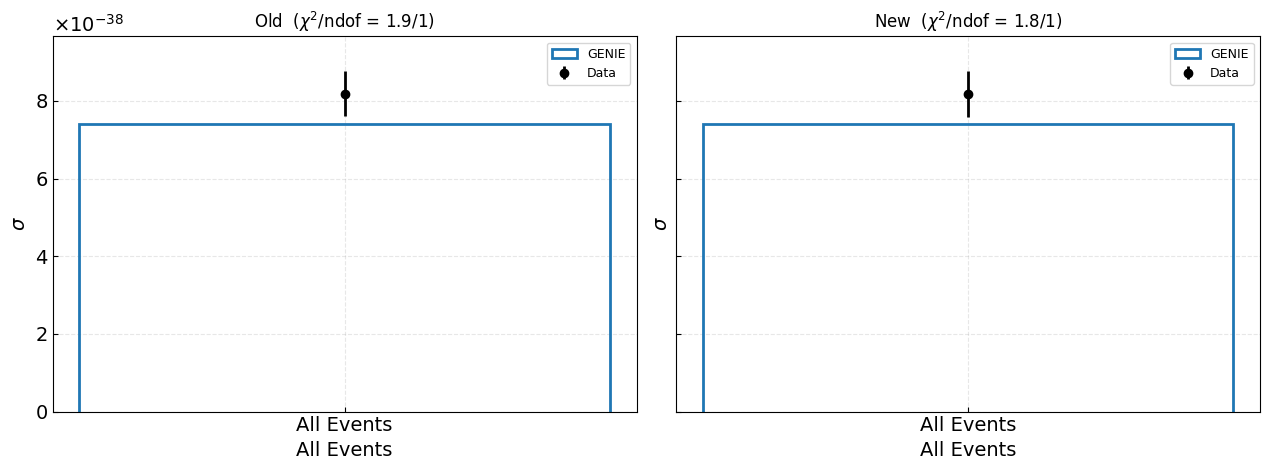

wrote /exp/sbnd/data/users/munjung/plots/numucc1p0pi/unfolding_genie_comparison/unfold_xsec__tki-del_Tp.png


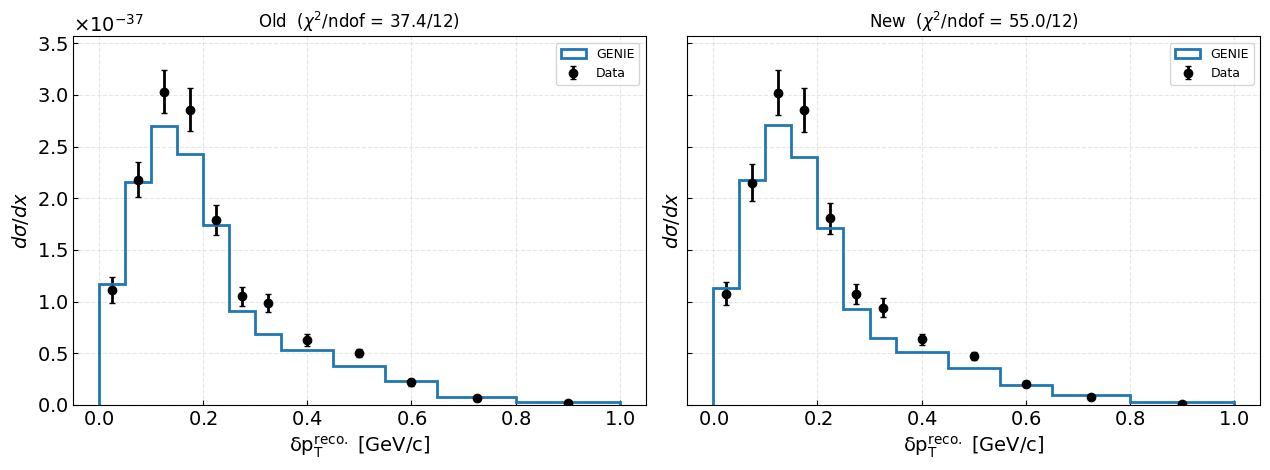

wrote /exp/sbnd/data/users/munjung/plots/numucc1p0pi/unfolding_genie_comparison/unfold_xsec__tki-del_alpha.png


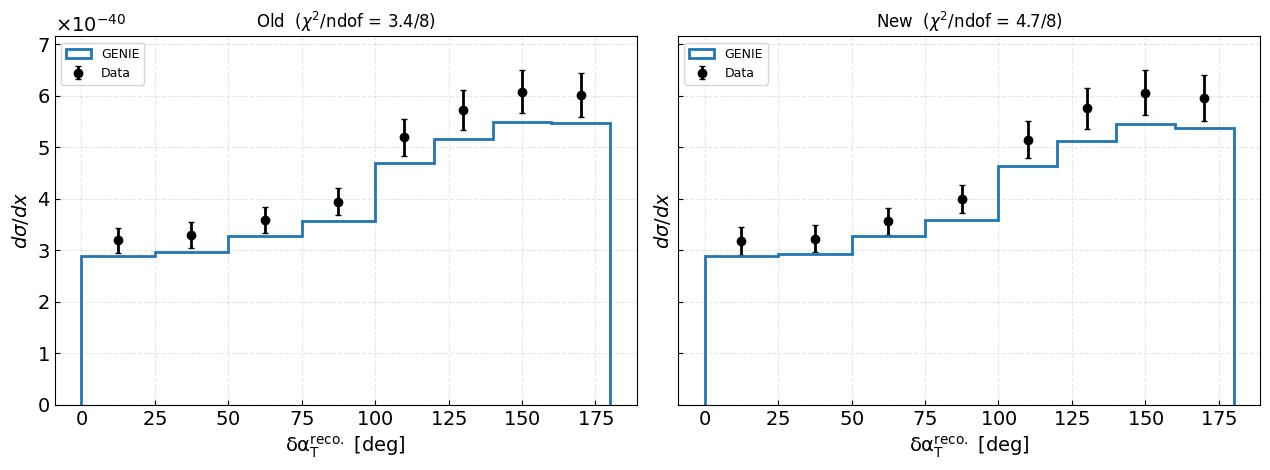

wrote /exp/sbnd/data/users/munjung/plots/numucc1p0pi/unfolding_genie_comparison/unfold_xsec__tki-del_phi.png


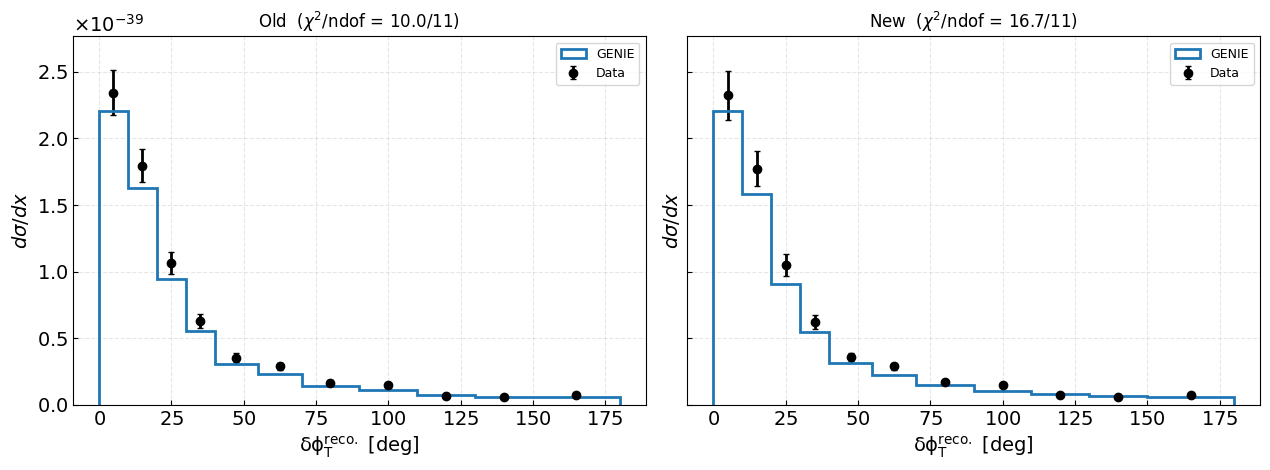

wrote /exp/sbnd/data/users/munjung/plots/numucc1p0pi/unfolding_genie_comparison/unfold_xsec__muon-p.png


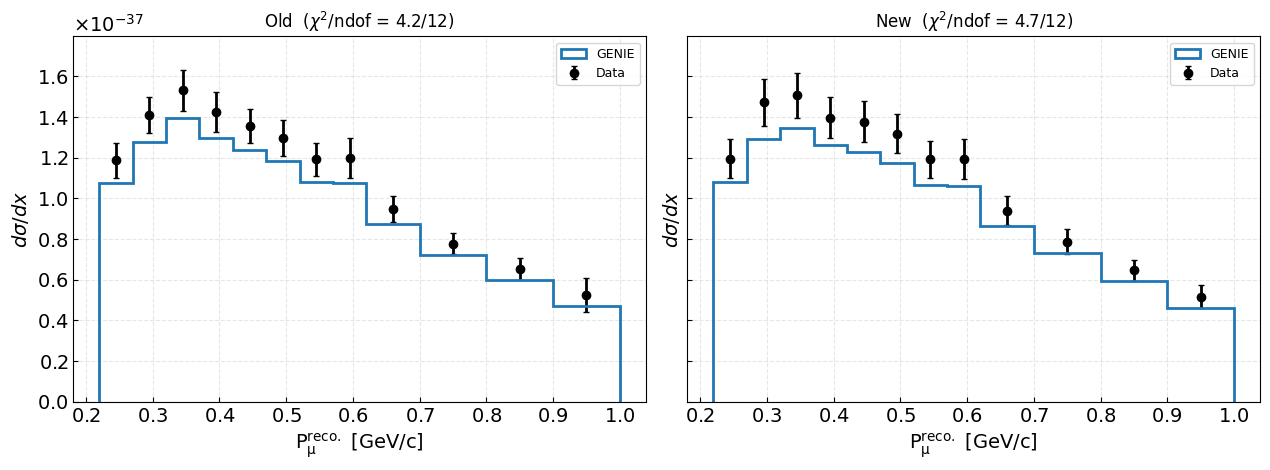

wrote /exp/sbnd/data/users/munjung/plots/numucc1p0pi/unfolding_genie_comparison/unfold_xsec__proton-p.png


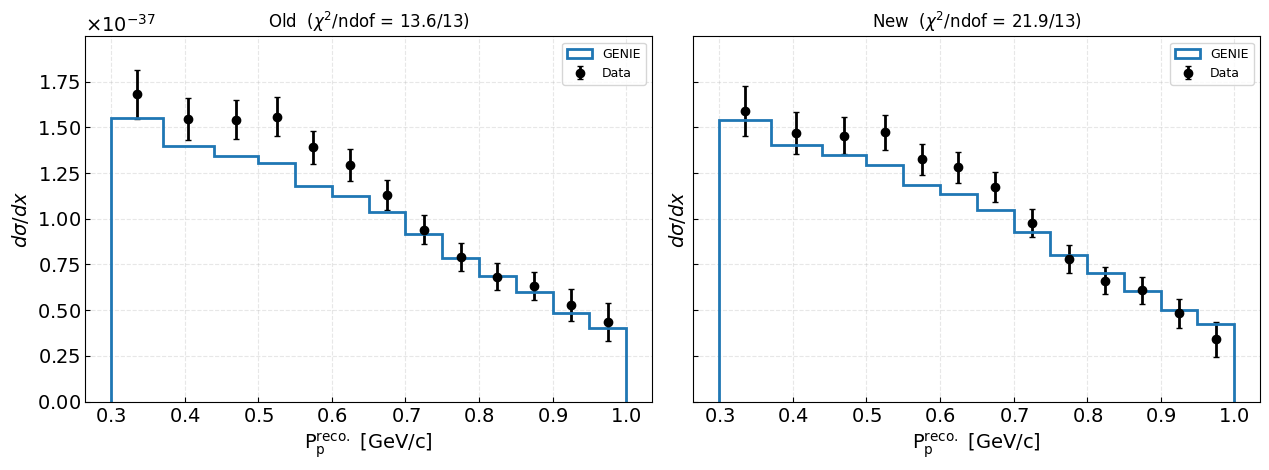

In [5]:
def _bin_widths(bins: np.ndarray) -> np.ndarray:
    bins = np.asarray(bins, dtype=float)
    return np.diff(bins) if len(bins) > 2 else np.array([1.0])


def plot_extracted_on_ax(ax, blob: dict, title: str, vsn: str) -> float:
    vc = blob["vc"]
    bins = np.asarray(blob["bins"], dtype=float)
    bw = _bin_widths(bins)
    bc = np.asarray(vc.bin_centers, dtype=float)
    unfold = blob["unfold"]
    model = np.asarray(blob["model"], dtype=float)

    U = np.asarray(unfold["unfold"], dtype=float) / bw
    err = np.sqrt(np.maximum(np.diag(unfold["UnfoldCov"]), 0.0)) / bw
    M = (np.asarray(unfold["AddSmear"], dtype=float) @ model) / bw

    is_int = len(bins) == 2
    if is_int:
        ax.errorbar([bc[0]], U, yerr=err, fmt="o", color="k", label="Data")
        ax.hist([bc[0]], bins=bins, weights=M, histtype="step", linewidth=2.0, color="C0", label="GENIE")
        ax.set_xticks([bc[0]])
        ax.set_xticklabels(["All Events"])
        ax.set_xlabel("All Events")
    else:
        ax.errorbar(bc, U, yerr=err, fmt="o", color="k", label="Data", capsize=2)
        ax.hist(bc, bins=bins, weights=M, histtype="step", linewidth=2.0, color="C0", label="GENIE")
        xlab = vc.var_labels[1] if getattr(vc, "var_labels", None) else vsn
        ax.set_xlabel(xlab)

    ax.set_ylabel(r"$d\sigma / dx$" if not is_int else r"$\sigma$")
    ax.set_title(f"{title}  ($\chi^2$/ndof = {blob['chi2']:.1f}/{blob['ndof']})", fontsize=12)
    ax.set_ylim(bottom=0)
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=9, loc="best")
    return float(np.nanmax(np.r_[U + err, M]))


for vsn in available:
    fig, axes = plt.subplots(1, 2, figsize=(12.8, 4.8), sharey=True)
    ymax = 0.0
    for ax, era, lab in zip(axes, ("old", "new"), ("Old", "New")):
        ymax = max(ymax, plot_extracted_on_ax(ax, results[era][vsn], lab, vsn))
    for ax in axes:
        ax.set_ylim(0.0, ymax * 1.1)
    fig.tight_layout()
    if SAVE_FIGS:
        out = OUT_DIR / f"unfold_xsec__{vsn}.png"
        fig.savefig(out, dpi=FIG_DPI, bbox_inches="tight")
        print("wrote", out)
    plt.show()
